# News Analytics: Feral Cats Media Coverage

This notebook provides a descriptive analysis of news coverage related to feral cats in Australia from 2017 to 2026.  
The goal is to examine how media attention, sentiment, and visibility changed over time.

The analysis focuses on four key indicators:

- **article_count** -- the number of articles about feral cats published in a given year;
- **tone_weighted** -- the weighted average tone of news coverage;
- **volume_intensity_mean** -- the mean volume intensity across observations within each year;
- **volume_intensity** -- the relative share of feral-cat-related articles in the broader news flow.

In this notebook, we:
1. review descriptive statistics;
2. visualize time trends;
3. inspect variable distributions using boxplots;
4. identify potential outliers;
5. examine correlations between news indicators.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
news = pd.read_csv('../datasets/news.csv')

In [4]:
news.describe()

,year,article_count,tone_weighted,volume_intensity_mean,volume_intensity
count,10.00000,10.00000,10.000000,10.000000,1.000000e+01
mean,2021.50000,535.80000,-2.332615,0.000504,5.070130e-06
std,3.02765,591.97575,1.326686,0.000295,3.201579e-06
min,2017.00000,57.00000,-5.721858,0.000065,6.693648e-07
25%,2019.25000,231.75000,-2.540825,0.000269,2.698815e-06
50%,2021.50000,352.50000,-1.992839,0.000524,5.214585e-06
75%,2023.75000,517.50000,-1.649336,0.000655,5.766158e-06
max,2026.00000,2014.00000,-0.819262,0.000946,1.119350e-05


In [7]:
# Select the main numeric variables for analysis
news_cols = [
    'article_count',
    'tone_weighted',
    'volume_intensity_mean',
    'volume_intensity'
]

**Time trends by year**

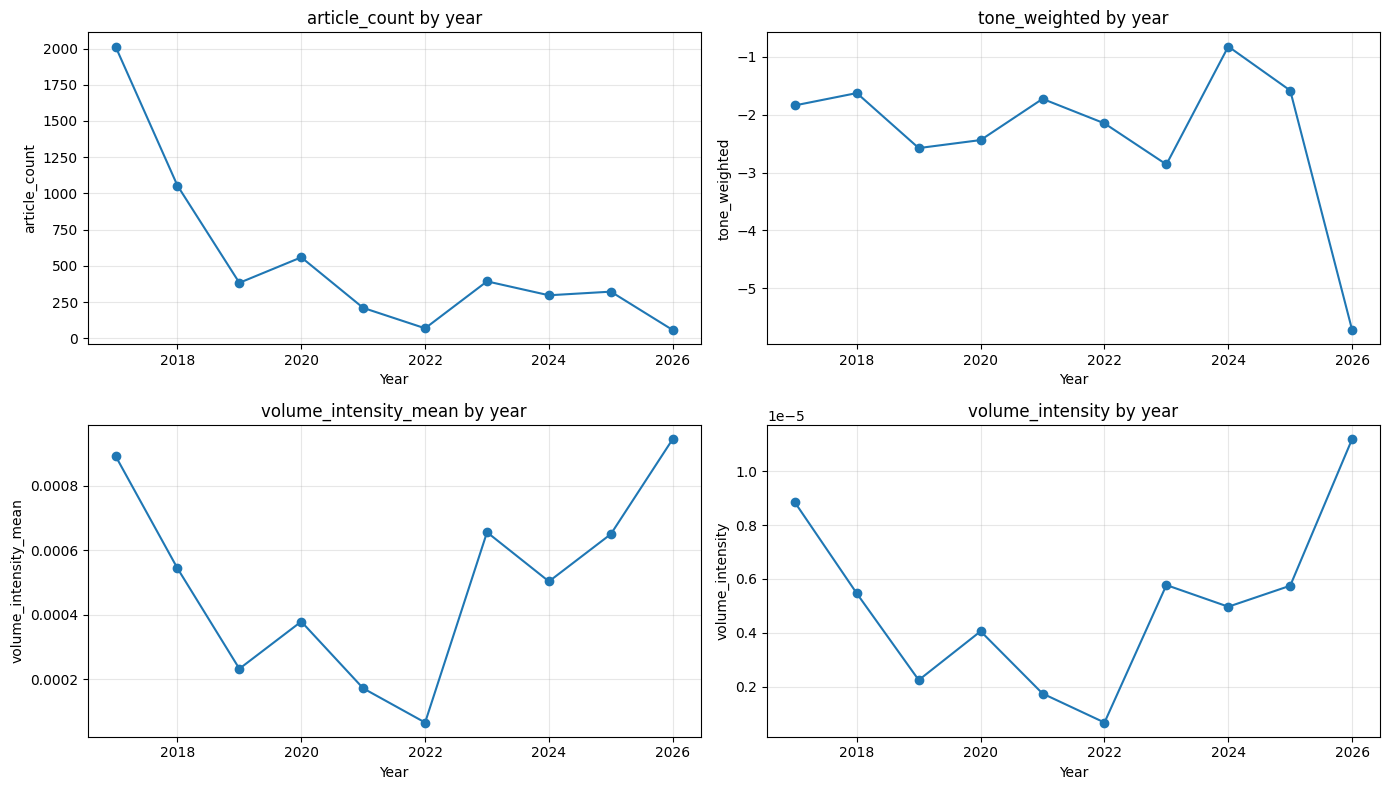

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(news_cols):
    axes[i].plot(news['year'], news[col], marker='o')
    axes[i].set_title(f'{col} by year')
    axes[i].set_xlabel('Year')
    axes[i].set_ylabel(col)
    axes[i].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Media attention to feral cats peaked at the beginning of the observed period and then decreased substantially, followed by a partial recovery in the middle years and a further decline in 2026. The weighted tone was negative across all years and reached its most negative value in 2026, although this observation is not fully comparable because the year is not yet complete. The volume indicators show that the topic was most visible in 2017, then declined, and later gained some visibility again in the final years of the sample, while still remaining relatively marginal within the broader news landscape (as we expected).

**Outliers**

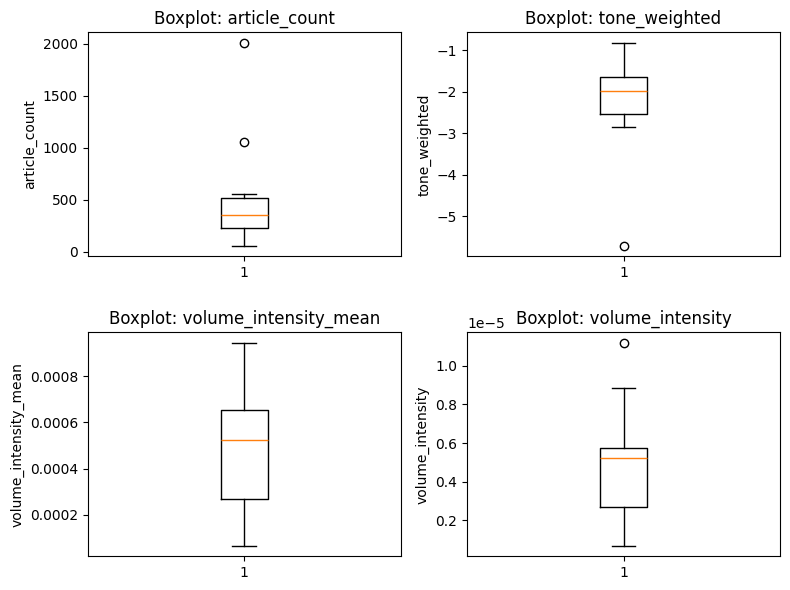

In [12]:
# Boxplots for potential outliers
fig, axes = plt.subplots(2, 2, figsize=(8, 6))
axes = axes.flatten()

for i, col in enumerate(news_cols):
    axes[i].boxplot(news[col], vert=True)
    axes[i].set_title(f'Boxplot: {col}')
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.show()

The boxplots suggest that article_count is the most unevenly distributed variable, with clear high-value outliers in the early years, especially 2017. tone_weighted also shows a notable outlier on the lower end, reflecting the unusually negative tone observed in 2026, while the two volume indicators appear more stable overall, with only volume_intensity showing a single upper-end outlier.

**Correlation analysis**

Pearson correlation:


,article_count,tone_weighted,volume_intensity_mean,volume_intensity
article_count,1.000,0.287,0.434,0.362
tone_weighted,0.287,1.000,-0.411,-0.541
volume_intensity_mean,0.434,-0.411,1.000,0.978
volume_intensity,0.362,-0.541,0.978,1.000


Spearman correlation:


,article_count,tone_weighted,volume_intensity_mean,volume_intensity
article_count,1.000,0.127,0.248,0.248
tone_weighted,0.127,1.000,-0.212,-0.212
volume_intensity_mean,0.248,-0.212,1.000,1.000
volume_intensity,0.248,-0.212,1.000,1.000


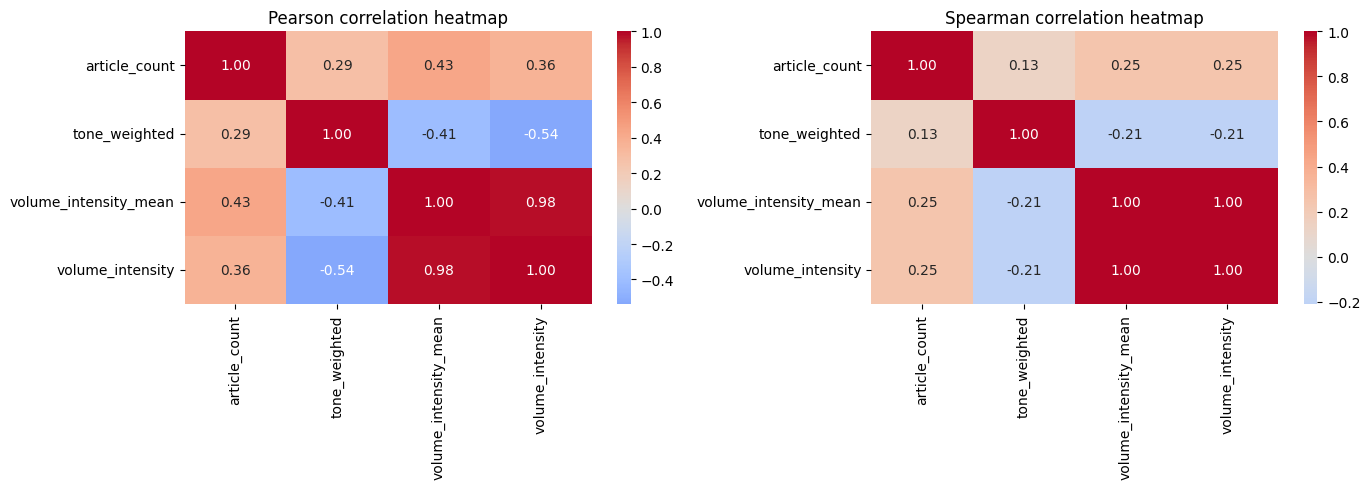

In [16]:
pearson_corr = news[news_cols].corr(method='pearson')
spearman_corr = news[news_cols].corr(method='spearman')

print("Pearson correlation:")
display(pearson_corr.round(3))

print("Spearman correlation:")
display(spearman_corr.round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(pearson_corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', ax=axes[0])
axes[0].set_title('Pearson correlation heatmap')

sns.heatmap(spearman_corr, annot=True, cmap='coolwarm', center=0, fmt='.2f', ax=axes[1])
axes[1].set_title('Spearman correlation heatmap')

plt.tight_layout()
plt.show()

The correlation analysis shows that the two volume measures are almost perfectly correlated, indicating that they capture nearly the same pattern of media visibility over time. By contrast, article_count has only weak to moderate positive correlations with the other indicators, while tone_weighted is moderately negatively correlated with the volume measures, suggesting that years with greater media visibility tended to be associated with more negative coverage.